# Máxima verossimilhança do zero

**Tema:** Estatística › Inferência e Estimação

Máxima verossimilhança (MLE) é o método de estimação mais importante que
existe. Regressão logística, GLMs, modelos de sobrevivência e **toda rede
neural treinada com entropia cruzada** são MLE por baixo do capô.

Neste notebook vamos implementá-lo do zero, ver a superfície de
verossimilhança com os próprios olhos, e derivar dela os erros-padrão que o
`statsmodels` reporta.

> **A inversão mental que o MLE exige:** a densidade $f(x \mid \theta)$ é
> normalmente lida como "dado o parâmetro, qual a chance deste dado?". A
> verossimilhança lê a **mesma função ao contrário**: o dado está fixo (você já
> o observou) e o parâmetro é a variável. $L(\theta) = f(x \mid \theta)$, mesma
> fórmula, leitura oposta.
>
> **Analogia:** você acha uma pegada. A densidade pergunta "se for um lobo,
> qual a chance desta pegada?". A verossimilhança pergunta "esta pegada é mais
> compatível com lobo ou com cachorro?". O MLE escolhe o animal que torna a
> pegada menos surpreendente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize

rng = np.random.default_rng(1234)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. O caso mais simples: estimar a taxa de uma moeda

Observamos 7 sucessos em 20 tentativas. Qual $p$ torna esse resultado o mais
provável possível?

$$L(p) = \binom{20}{7} p^7 (1-p)^{13}$$

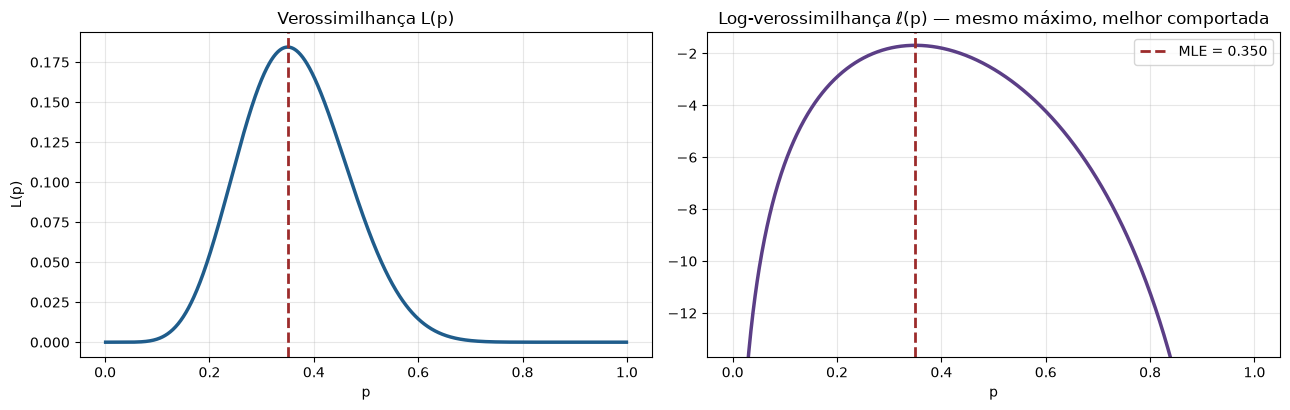

MLE por busca numérica : 0.3497
MLE analítico (k/n)    : 0.3500

Por que maximizar o LOG? Três razões:
  1. O máximo é o mesmo (log é monotônica crescente).
  2. Produtos viram somas -> derivadas ficam tratáveis.
  3. Estabilidade numérica: o produto de 10.000 probabilidades
     dá underflow. Veja: 0.3**1000 = 0.0


In [2]:
n_tentativas, n_sucessos = 20, 7
p_grade = np.linspace(0.001, 0.999, 1000)

# Verossimilhança e log-verossimilhança
veros = stats.binom.pmf(n_sucessos, n_tentativas, p_grade)
log_veros = stats.binom.logpmf(n_sucessos, n_tentativas, p_grade)

p_mle_numerico = p_grade[np.argmax(log_veros)]
p_mle_analitico = n_sucessos / n_tentativas   # a solução fechada é a média amostral

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
ax1.plot(p_grade, veros, lw=2.5, color=AZUL)
ax1.axvline(p_mle_analitico, ls="--", color=VERMELHO, lw=2)
ax1.set_title("Verossimilhança L(p)")
ax1.set_xlabel("p")
ax1.set_ylabel("L(p)")

ax2.plot(p_grade, log_veros, lw=2.5, color=ROXO)
ax2.axvline(p_mle_analitico, ls="--", color=VERMELHO, lw=2,
            label=f"MLE = {p_mle_analitico:.3f}")
ax2.set_ylim(log_veros.max() - 12, log_veros.max() + 0.5)
ax2.set_title("Log-verossimilhança ℓ(p) — mesmo máximo, melhor comportada")
ax2.set_xlabel("p")
ax2.legend()
plt.tight_layout()
plt.show()

print(f"MLE por busca numérica : {p_mle_numerico:.4f}")
print(f"MLE analítico (k/n)    : {p_mle_analitico:.4f}")
print("\nPor que maximizar o LOG? Três razões:")
print("  1. O máximo é o mesmo (log é monotônica crescente).")
print("  2. Produtos viram somas -> derivadas ficam tratáveis.")
print("  3. Estabilidade numérica: o produto de 10.000 probabilidades")
print(f"     dá underflow. Veja: 0.3**1000 = {0.3**1000}")

## 2. Derivando o MLE à mão (o único caso em que vale a pena)

$$\ell(p) = k \log p + (n-k)\log(1-p) + \text{const}$$

$$\frac{d\ell}{dp} = \frac{k}{p} - \frac{n-k}{1-p} = 0
\quad \Longrightarrow \quad \hat{p} = \frac{k}{n}$$

O MLE da taxa é simplesmente a proporção observada. Confirmamos numericamente
que a derivada é zero exatamente ali.

In [3]:
def derivada_log_veros(p, k=n_sucessos, n=n_tentativas):
    return k / p - (n - k) / (1 - p)

for p in [0.20, 0.30, 0.35, 0.40, 0.50]:
    d = derivada_log_veros(p)
    direcao = "subir p" if d > 0 else "descer p" if d < 0 else "MÁXIMO"
    print(f"p = {p:.2f} -> dℓ/dp = {d:+9.3f}   ({direcao})")

p = 0.20 -> dℓ/dp =   +18.750   (subir p)
p = 0.30 -> dℓ/dp =    +4.762   (subir p)
p = 0.35 -> dℓ/dp =    +0.000   (MÁXIMO)
p = 0.40 -> dℓ/dp =    -4.167   (descer p)
p = 0.50 -> dℓ/dp =   -12.000   (descer p)


## 3. Dois parâmetros: a superfície de verossimilhança

Com dois parâmetros a verossimilhança vira uma superfície. Vamos ajustar uma
normal e ver o formato dessa superfície — porque o formato **é** a incerteza.

In [4]:
dados = rng.normal(loc=25.0, scale=4.0, size=60)

def neg_log_veros_normal(params, x):
    """Log-verossimilhança negativa (otimizadores minimizam, então negamos)."""
    mu, log_sigma = params           # parametrizamos log(sigma) para evitar sigma<0
    sigma = np.exp(log_sigma)
    return -np.sum(stats.norm.logpdf(x, mu, sigma))

resultado = optimize.minimize(neg_log_veros_normal, x0=[0.0, 0.0], args=(dados,),
                              method="BFGS")
mu_mle, sigma_mle = resultado.x[0], np.exp(resultado.x[1])

print(f"MLE numérico  : μ = {mu_mle:.4f}, σ = {sigma_mle:.4f}")
print(f"MLE analítico : μ = {dados.mean():.4f}, σ = {dados.std(ddof=0):.4f}")
print("\nNote: o MLE de σ usa ddof=0 — ele é VIESADO em amostras finitas.")
print(f"      (o estimador não-viesado daria σ = {dados.std(ddof=1):.4f})")

MLE numérico  : μ = 24.8469, σ = 4.6719
MLE analítico : μ = 24.8469, σ = 4.6719

Note: o MLE de σ usa ddof=0 — ele é VIESADO em amostras finitas.
      (o estimador não-viesado daria σ = 4.7114)


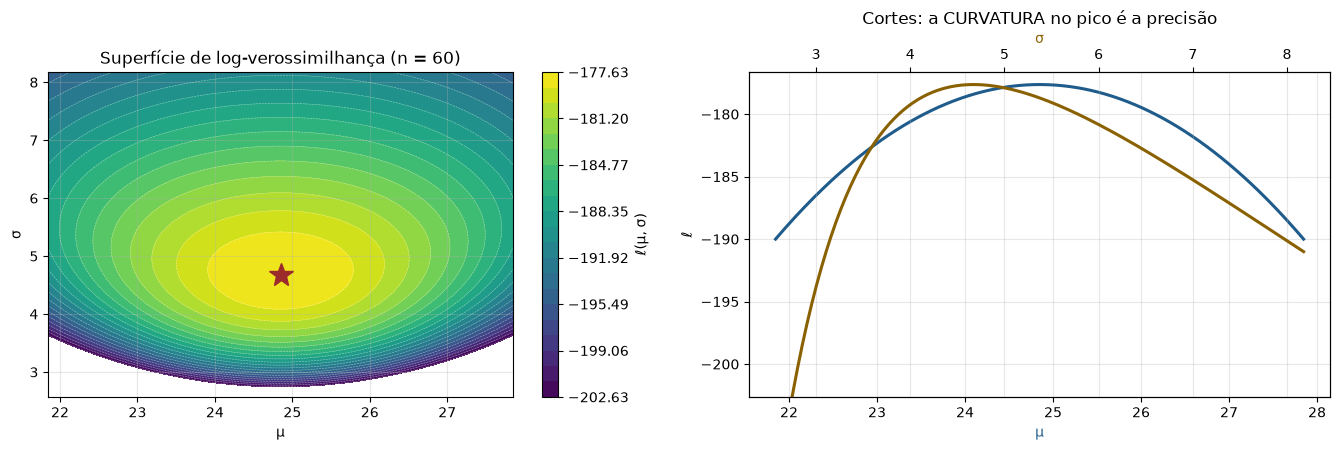

In [5]:
mu_grade = np.linspace(mu_mle - 3, mu_mle + 3, 220)
sigma_grade = np.linspace(sigma_mle * 0.55, sigma_mle * 1.75, 220)
MU, SIGMA = np.meshgrid(mu_grade, sigma_grade)

Z = np.array([[-neg_log_veros_normal([m, np.log(s)], dados)
               for m in mu_grade] for s in sigma_grade])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.6))
niveis = mu_mle and np.linspace(Z.max() - 25, Z.max(), 22)
cf = ax1.contourf(MU, SIGMA, Z, levels=niveis, cmap="viridis")
ax1.contour(MU, SIGMA, Z, levels=niveis, colors="white", linewidths=0.4, alpha=0.5)
ax1.plot(mu_mle, sigma_mle, "*", ms=18, color=VERMELHO)
ax1.set_xlabel("μ")
ax1.set_ylabel("σ")
ax1.set_title("Superfície de log-verossimilhança (n = 60)")
plt.colorbar(cf, ax=ax1, label="ℓ(μ, σ)")

# Cortes: como ℓ varia em cada direção separadamente
ax2.plot(mu_grade, [-neg_log_veros_normal([m, np.log(sigma_mle)], dados)
                    for m in mu_grade], lw=2.2, color=AZUL, label="corte em μ (σ fixo)")
ax2b = ax2.twiny()
ax2b.plot(sigma_grade, [-neg_log_veros_normal([mu_mle, np.log(s)], dados)
                        for s in sigma_grade], lw=2.2, color=AMBAR,
          label="corte em σ (μ fixo)")
ax2.set_xlabel("μ", color=AZUL)
ax2b.set_xlabel("σ", color=AMBAR)
ax2.set_ylabel("ℓ")
ax2.set_ylim(Z.max() - 25, Z.max() + 1)
ax2.set_title("Cortes: a CURVATURA no pico é a precisão")
plt.tight_layout()
plt.show()

**A curvatura no pico é a informação.** Um pico agudo significa que valores
vizinhos do parâmetro são muito menos verossímeis — os dados distinguem bem, e
a estimativa é precisa. Um pico achatado significa o contrário.

Isso é literalmente a definição de informação de Fisher: o negativo da segunda
derivada da log-verossimilhança.

## 4. Do pico ao erro-padrão: a matriz de informação

$$I(\theta) = -\mathbb{E}\left[ \frac{\partial^2 \ell}{\partial \theta^2} \right]
\qquad\qquad
\widehat{\text{Var}}(\hat{\theta}) = \left[ I(\hat{\theta}) \right]^{-1}$$

Na prática usamos a **Hessiana observada** no ponto de máximo. É exatamente
assim que o `statsmodels` calcula os erros-padrão que aparecem no `summary()`.

In [6]:
def hessiana_numerica(f, x0, h=1e-5):
    """Segunda derivada por diferenças finitas centrais."""
    n = len(x0)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            xpp, xpm, xmp, xmm = (np.array(x0, float) for _ in range(4))
            xpp[i] += h; xpp[j] += h
            xpm[i] += h; xpm[j] -= h
            xmp[i] -= h; xmp[j] += h
            xmm[i] -= h; xmm[j] -= h
            H[i, j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4 * h * h)
    return H


# Reparametrizamos para (mu, sigma) direto, para o erro-padrão sair na escala útil
def nll(params):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    return -np.sum(stats.norm.logpdf(dados, mu, sigma))


theta_hat = np.array([dados.mean(), dados.std(ddof=0)])
H = hessiana_numerica(nll, theta_hat)      # Hessiana da NEGATIVA = informação observada
cov = np.linalg.inv(H)
erros_padrao = np.sqrt(np.diag(cov))

print("Estimativas e erros-padrão via matriz de informação:")
print(f"   μ = {theta_hat[0]:8.4f}  ±  {erros_padrao[0]:.4f}")
print(f"   σ = {theta_hat[1]:8.4f}  ±  {erros_padrao[1]:.4f}")
print()
print("Confirmação pelas fórmulas analíticas conhecidas:")
print(f"   EP(μ) = σ/√n        = {theta_hat[1]/np.sqrt(len(dados)):.4f}")
print(f"   EP(σ) = σ/√(2n)     = {theta_hat[1]/np.sqrt(2*len(dados)):.4f}")
print()
print("Correlação entre as estimativas de μ e σ:")
print(f"   {cov[0,1] / (erros_padrao[0]*erros_padrao[1]):.4f}  "
      "(≈ 0: para a normal, μ e σ são ortogonais)")

Estimativas e erros-padrão via matriz de informação:
   μ =  24.8469  ±  0.6031
   σ =   4.6719  ±  0.4265

Confirmação pelas fórmulas analíticas conhecidas:
   EP(μ) = σ/√n        = 0.6031
   EP(σ) = σ/√(2n)     = 0.4265

Correlação entre as estimativas de μ e σ:
   -0.0001  (≈ 0: para a normal, μ e σ são ortogonais)


> **Este é o mecanismo por trás de todo `summary()` que você já viu.** Quando o
> `statsmodels` reporta `coef`, `std err`, `z` e `P>|z|`, ele: (1) maximizou a
> log-verossimilhança para achar `coef`; (2) inverteu a Hessiana para achar
> `std err`; (3) dividiu um pelo outro para achar `z`; (4) consultou a normal
> para achar o p-valor. Nada mais.

## 5. MLE aplicado: um problema que não tem fórmula fechada

Dados **censurados** são o pão de cada dia em análise de sobrevivência e churn:
você sabe que o cliente ficou pelo menos 8 meses, mas ele ainda é cliente —
você não sabe quanto vai ficar no total.

Ignorar a censura (usar só quem já saiu) enviesa tudo para baixo. O MLE trata
isso corretamente porque a verossimilhança de uma observação censurada é
$P(T > c) = S(c)$, a função de sobrevivência.

In [7]:
LAMBDA_VERDADEIRO = 1 / 18.0    # tempo médio de vida real: 18 meses
n_clientes = 1200
tempo_real = rng.exponential(1 / LAMBDA_VERDADEIRO, n_clientes)

# Observamos a base por 12 meses. Quem passou disso está CENSURADO à direita.
JANELA = 12.0
observado = np.minimum(tempo_real, JANELA)
evento = tempo_real <= JANELA          # True = churnou (evento observado)

print(f"Tempo médio de vida VERDADEIRO : {1/LAMBDA_VERDADEIRO:.2f} meses")
print(f"Clientes que churnaram na janela: {evento.sum()} de {n_clientes} "
      f"({evento.mean():.1%})")
print(f"Clientes censurados             : {(~evento).sum()}")


def nll_exponencial_censurada(log_lam, tempo, evento):
    """Verossimilhança com censura à direita.

    Para quem churnou : contribui com a DENSIDADE  f(t) = λ e^(-λt)
    Para quem ficou   : contribui com a SOBREVIVÊNCIA S(t) = e^(-λt)
    """
    lam = np.exp(log_lam)
    log_f = np.log(lam) - lam * tempo          # log da densidade
    log_S = -lam * tempo                       # log da sobrevivência
    return -np.sum(np.where(evento, log_f, log_S))


res = optimize.minimize_scalar(nll_exponencial_censurada,
                               bounds=(-6, 2), method="bounded",
                               args=(observado, evento))
lam_mle = np.exp(res.x)

# Comparação com as abordagens ingênuas
media_ingenua_todos = observado.mean()                   # trata censura como churn
media_so_churnados = observado[evento].mean()            # descarta censurados

print(f"\n{'abordagem':46s} {'vida média estimada':>20s} {'erro':>10s}")
print("-" * 80)
alvo = 1 / LAMBDA_VERDADEIRO
for nome, valor in [
        ("(A) Média de todos, censura tratada como churn", media_ingenua_todos),
        ("(B) Média só de quem churnou (descarta censura)", media_so_churnados),
        ("(C) MLE com censura tratada corretamente", 1 / lam_mle)]:
    print(f"{nome:46s} {valor:>20.2f} {(valor-alvo)/alvo:>9.1%}")

Tempo médio de vida VERDADEIRO : 18.00 meses
Clientes que churnaram na janela: 586 de 1200 (48.8%)
Clientes censurados             : 614

abordagem                                       vida média estimada       erro
--------------------------------------------------------------------------------
(A) Média de todos, censura tratada como churn                 8.80    -51.1%
(B) Média só de quem churnou (descarta censura)                 5.45    -69.7%
(C) MLE com censura tratada corretamente                      18.02      0.1%


As abordagens ingênuas subestimam a vida média em dezenas de por cento. O MLE
com censura acerta.

> **No mercado:** este erro aparece toda vez que alguém calcula LTV (*lifetime
> value*) como "receita média ÷ churn médio" usando só clientes que já saíram.
> O resultado subestima sistematicamente o valor da base — e leva a subinvestir
> em aquisição. Modelos de sobrevivência existem exatamente para isso.

## 6. As propriedades assintóticas, verificadas

     n   média do MLE      viés   DP observado    1/√(n·I)
------------------------------------------------------------
    10         0.4443    0.0443         0.1581      0.1265
    30         0.4133    0.0133         0.0780      0.0730
   100         0.4044    0.0044         0.0409      0.0400
   500         0.4005    0.0005         0.0180      0.0179


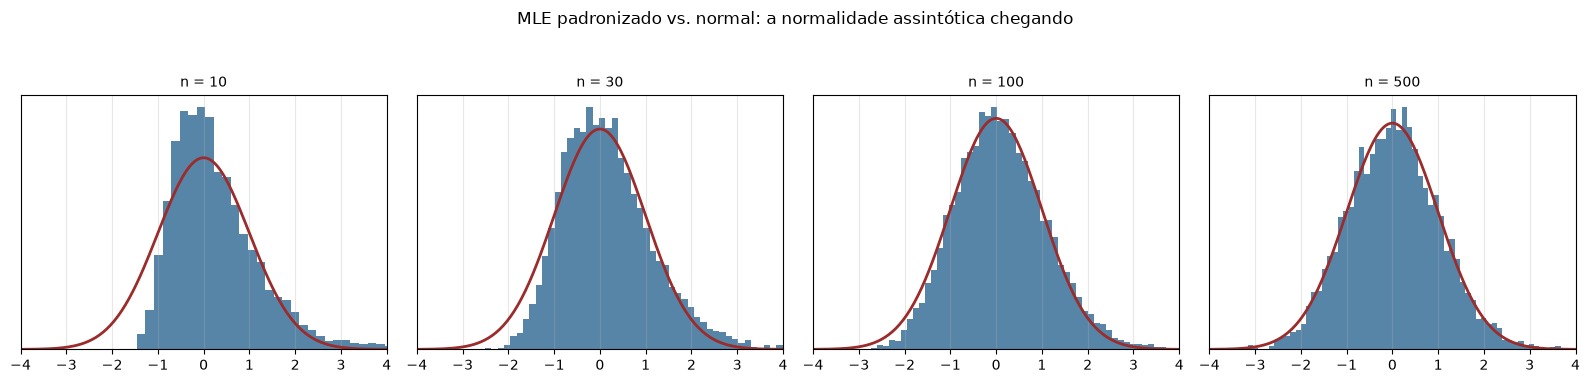

In [8]:
N_REPLICAS = 6_000
tamanhos = [10, 30, 100, 500]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
print(f"{'n':>6s} {'média do MLE':>14s} {'viés':>9s} {'DP observado':>14s} "
      f"{'1/√(n·I)':>11s}")
print("-" * 60)
LAM = 0.4
for ax, n in zip(axes, tamanhos):
    amostras = rng.exponential(1 / LAM, size=(N_REPLICAS, n))
    lam_hat = 1 / amostras.mean(axis=1)         # MLE da exponencial = 1/média
    z = (lam_hat - LAM) / lam_hat.std(ddof=1)
    ax.hist(z, bins=60, density=True, color=AZUL, alpha=0.75, edgecolor="none")
    grade = np.linspace(-4, 4, 200)
    ax.plot(grade, stats.norm.pdf(grade), lw=2, color=VERMELHO)
    ax.set_xlim(-4, 4)
    ax.set_title(f"n = {n}", fontsize=10)
    ax.set_yticks([])
    # Informação de Fisher da exponencial: I(λ) = 1/λ²  ->  EP = λ/√n
    print(f"{n:>6d} {lam_hat.mean():>14.4f} {lam_hat.mean()-LAM:>9.4f} "
          f"{lam_hat.std(ddof=1):>14.4f} {LAM/np.sqrt(n):>11.4f}")
plt.suptitle("MLE padronizado vs. normal: a normalidade assintótica chegando", y=1.05)
plt.tight_layout()
plt.show()

Leia a tabela junto com os gráficos:

* O **viés** encolhe conforme $n$ cresce (o MLE é viesado em amostra finita,
  consistente no limite).
* O **desvio-padrão observado** converge para $\lambda/\sqrt{n}$, que é o
  erro-padrão previsto pela informação de Fisher.
* O **histograma** vai ficando normal.

As três propriedades assintóticas em um só experimento.

## 7. Exercícios

1. Derive à mão o MLE da Poisson e confirme que é $\hat{\lambda} = \bar{x}$.
   Depois calcule $I(\lambda)$ e confirme que $\text{EP} = \sqrt{\lambda/n}$.
2. Implemente o MLE de uma **regressão logística** do zero (log-verossimilhança
   + `scipy.optimize`). Compare os coeficientes e erros-padrão com os do
   `statsmodels`. Eles devem bater em 4 casas decimais.
3. Ajuste uma Weibull censurada (em vez da exponencial) aos dados da seção 5.
   Você recupera o parâmetro de forma corretamente? O que acontece se a janela
   de observação for muito curta?
4. A verossimilhança de uma **mistura** tem múltiplos máximos locais. Rode o
   otimizador da mistura de 2 normais a partir de 20 pontos iniciais
   diferentes. Quantos ótimos distintos você encontra? Isso explica por que o
   algoritmo EM precisa de múltiplas inicializações.

## Próximo passo

`03-intervalos-e-bootstrap.ipynb` — o que um intervalo de confiança realmente
promete, e como obter um para qualquer estatística.